## The Data

At this link, you will find a dataset containing information about heart disease patients: https://www.dropbox.com/scl/fi/0vrpdnq5asmeulc4gd50y/ha_1.csv?rlkey=ciisalceotl77ffqhqe3kujzv&dl=1

A description of the original dataset can be found here: https://archive.ics.uci.edu/dataset/45/heart+disease (However, this dataset has been cleaned and reduced, and the people have been given fictious names.)

## 1. Logistic Regression

Fit a Logistic Regression using only `age` and `chol` (cholesterol) as predictors.

For a 55 year old, how high would their cholesterol need to be for the doctors to predict heart disease is present?

How high for the doctors to estimate a 90% chance that heart disease is present?

In [3]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np

dat = pd.read_csv('ha_1.csv')

y = (dat['diagnosis'] == 'Disease').astype(int)  # Disease=1, No Disease=0
X = dat[['age', 'chol']]

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression())
])
pipe.fit(X, y)

coef = pipe.named_steps['logreg'].coef_[0]
intercept = pipe.named_steps['logreg'].intercept_[0]
scaler = pipe.named_steps['scaler']

# For a 55-year-old, cholesterol for P=0.5 & P=0.9
def chol_threshold(age, p_target):
    z = np.log(p_target / (1 - p_target))
    # Use means and stds from the scaler
    age_scaled = (age - scaler.mean_[0]) / scaler.scale_[0]
    # Solve: z = intercept + coef_age*age_scaled + coef_chol*chol_scaled
    chol_scaled = (z - intercept - coef[0]*age_scaled) / coef[1]
    chol = chol_scaled * scaler.scale_[1] + scaler.mean_[1]
    return chol

chol_50 = chol_threshold(55, 0.5)
chol_90 = chol_threshold(55, 0.9)
print(f"Cholesterol for 50% prediction: {chol_50:.2f}")
print(f"Cholesterol for 90% prediction: {chol_90:.2f}")


Cholesterol for 50% prediction: 367.72
Cholesterol for 90% prediction: -846.70


## 2. Linear Discriminant Analysis

Fit an LDA model using only `age` and `chol` (cholesterol)  as predictors.

For a 55 year old, how high would their cholesterol need to be for the doctors to predict heart disease is present?

In [4]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = Pipeline([
    ('scaler', StandardScaler()),
    ('lda', LinearDiscriminantAnalysis())
])
lda.fit(X, y)

coef = lda.named_steps['lda'].coef_[0]
intercept = lda.named_steps['lda'].intercept_[0]
scaler = lda.named_steps['scaler']

def chol_LDA(age, p_target=0.5):
    # For LDA, decision boundary for class 1 vs 0 is: coef0*x0 + coef1*x1 + intercept = 0 for p=0.5
    age_scaled = (age - scaler.mean_[0]) / scaler.scale_[0]
    chol_scaled = (- intercept - coef[0]*age_scaled) / coef[1]
    chol = chol_scaled * scaler.scale_[1] + scaler.mean_[1]
    return chol

chol_lda = chol_LDA(55)
print(f"Cholesterol for LDA 50% boundary: {chol_lda:.2f}")


Cholesterol for LDA 50% boundary: 368.24


## 3. Support Vector Classifier

Fit an SVC model using only `age` and `chol` as predictors.  Don't forget to tune the regularization parameter.

For a 55 year old, how high would their cholesterol need to be for the doctors to predict heart disease is present?

In [5]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

svc = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='linear', probability=True))
])

param_grid = {'svc__C': [0.01, 0.1, 1, 10]}
grid = GridSearchCV(svc, param_grid, cv=5)
grid.fit(X, y)

svc_best = grid.best_estimator_
coef = svc_best.named_steps['svc'].coef_[0]
intercept = svc_best.named_steps['svc'].intercept_[0]
scaler = svc_best.named_steps['scaler']

def chol_SVC(age, p_target=0.5):
    age_scaled = (age - scaler.mean_[0]) / scaler.scale_[0]
    chol_scaled = (-intercept - coef[0]*age_scaled) / coef[1]
    chol = chol_scaled * scaler.scale_[1] + scaler.mean_[1]
    return chol

chol_svc = chol_SVC(55)
print(f"Cholesterol for SVC boundary: {chol_svc:.2f}")


Cholesterol for SVC boundary: 312.66


## 4. Comparing Decision Boundaries

Make a scatterplot of `age` and `chol`, coloring the points by their true disease outcome.  Add a line to the plot representing the **linear separator** (aka **decision boundary**) for each of the three models above.

/usr/local/lib/python3.12/dist-packages/plotnine/scales/scale_manual.py:39: PlotnineWarning: The palette of scale_color_manual can return a maximum of 3 values. 5 were requested from it.
/usr/local/lib/python3.12/dist-packages/plotnine/scales/scale_manual.py:39: PlotnineWarning: The palette of scale_color_manual can return a maximum of 3 values. 5 were requested from it.


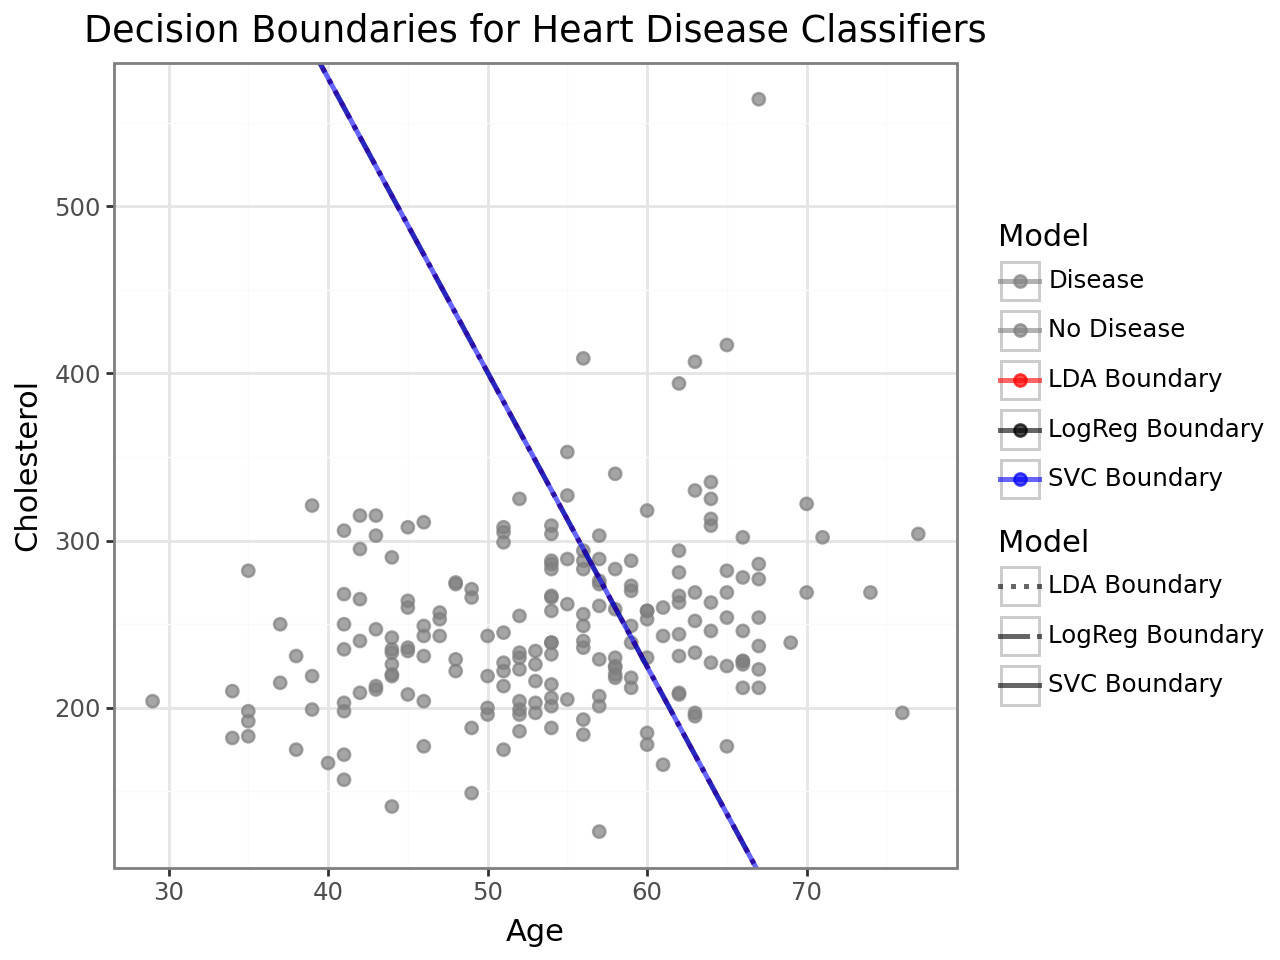

In [8]:
from plotnine import ggplot, aes, geom_point, labs, theme_bw, geom_abline, scale_color_manual, scale_linetype_manual
import pandas as pd

df_plot = dat.copy()
df_plot['diagnosis_bin'] = (df_plot['diagnosis'] == 'Disease').astype(int)

# Calculate intercepts and slopes for unscaled data using the previously defined functions
# For Logistic Regression
logreg_intercept = chol_threshold(0, 0.5)
logreg_slope = chol_threshold(1, 0.5) - logreg_intercept

# For LDA
lda_intercept = chol_LDA(0)
lda_slope = chol_LDA(1) - lda_intercept

# For SVC
svc_intercept = chol_SVC(0)
svc_slope = chol_SVC(1) - svc_intercept

# Create a DataFrame for the decision boundaries to easily manage legend aesthetics
lines_df = pd.DataFrame({
    'model': ['LogReg Boundary', 'LDA Boundary', 'SVC Boundary'],
    'intercept': [logreg_intercept, lda_intercept, svc_intercept],
    'slope': [logreg_slope, lda_slope, svc_slope],
    'line_color': ['black', 'red', 'blue'],
    'line_linetype': ['dashdot', 'dotted', 'solid']
})

p = (
    ggplot(df_plot, aes(x='age', y='chol', color='diagnosis'))
    + geom_point(size=2, alpha=0.7)
    # Use geom_abline with aes for intercept, slope, color, and linetype, referring to lines_df
    + geom_abline(aes(intercept='intercept', slope='slope', color='model', linetype='model'),
                  data=lines_df, size=1, alpha=0.6)
    + labs(x='Age', y='Cholesterol', title='Decision Boundaries for Heart Disease Classifiers')
    + theme_bw()
    # Manually define colors and linetypes for the legend
    + scale_color_manual(values=lines_df.set_index('model')['line_color'].to_dict(), name='Model')
    + scale_linetype_manual(values=lines_df.set_index('model')['line_linetype'].to_dict(), name='Model')
)
p
